In [2]:
%pip install seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/raynagollapalli/Downloads/cumulative.csv")

# Basic inspection
df.head()
df.info()
df['koi_disposition'].value_counts()
df['koi_pdisposition'].value_counts()


Note: you may need to restart the kernel to use updated packages.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_ti

koi_pdisposition
FALSE POSITIVE    5068
CANDIDATE         4496
Name: count, dtype: int64

In [6]:
df["agreement"] = df["koi_disposition"] == df["koi_pdisposition"]
df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag,agreement
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,False
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,False
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436,True
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597,True
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509,False


<Axes: xlabel='koi_disposition'>

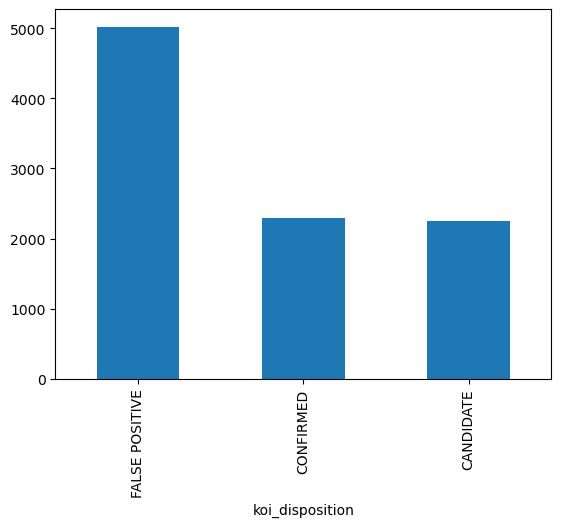

In [7]:
df['koi_disposition'].value_counts().plot(kind='bar')

In [4]:
comparison = pd.crosstab(df['koi_disposition'], df['koi_pdisposition'])
comparison

koi_pdisposition,CANDIDATE,FALSE POSITIVE
koi_disposition,,
CANDIDATE,2248,0
CONFIRMED,2248,45
FALSE POSITIVE,0,5023


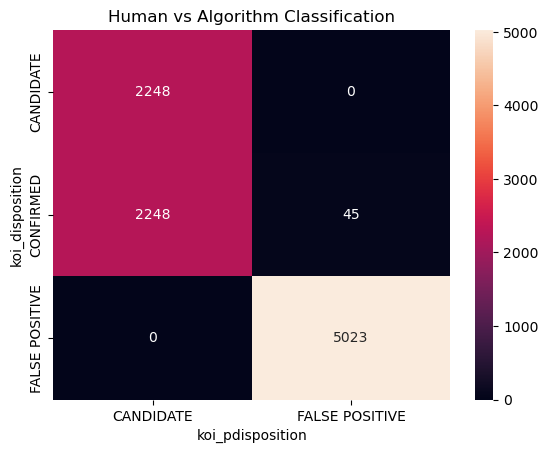

In [5]:
sns.heatmap(comparison, annot=True, fmt="d")
plt.title("Human vs Algorithm Classification")
plt.show()

([<matplotlib.patches.Wedge at 0x167ea38c0>,
 [Text(-0.8024490935325725, 0.7523798590398024, 'True'),
  Text(0.8024489799263653, -0.7523799802062359, 'False')],
 [Text(-0.43769950556322135, 0.41038901402171035, '76.0%'),
  Text(0.4376994435961992, -0.41038908011249225, '24.0%')])

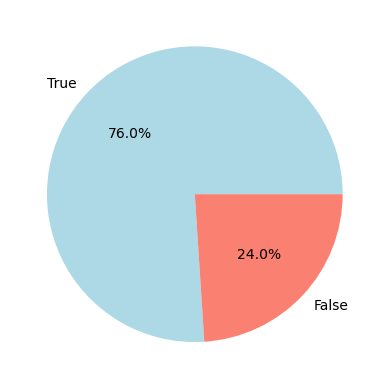

In [11]:
agreement_rate = df['agreement'].value_counts(normalize=True)
plt.pie(agreement_rate, labels=agreement_rate.index, autopct='%1.1f%%', colors=['lightblue', 'salmon'])

<Axes: xlabel='koi_disposition', ylabel='koi_score'>

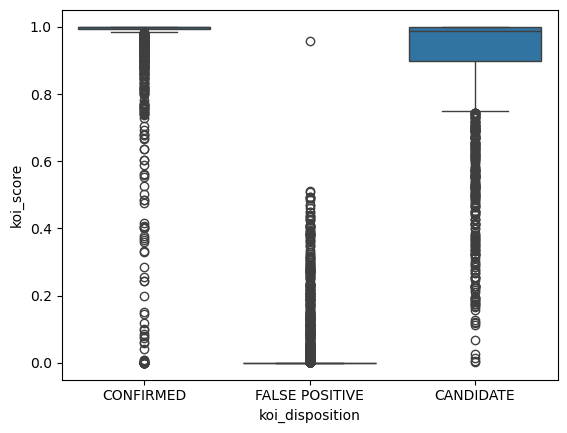

In [9]:
sns.boxplot(x='koi_disposition', y='koi_score', data=df)